In [1]:
import os
import platform
import subprocess
import re

import pandas as pd
import numpy as np
from scipy.stats import norm

import arviz as az
import pymc as pm
import pytensor.tensor as at
from dataclasses import dataclass
from typing import List, Tuple, Dict, Union


import matplotlib.pyplot as plt

In [2]:
az.style.use("arviz-doc")

## Helper Functions

### System utils

In [3]:
def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

### Data Processing

In [4]:
@dataclass
class CensoredDataWithinWorker:
    y: List[float]
    lower_limits: List[float]
    upper_limits: List[float]
    uncensored_data: List[float]
    censored_data: List[float]
    censored_limits: List[float]
    subgroup: List[int]  # Add a list to track subgroup membership

def define_observed_lower_upper(expo_data: List[List[str]], oel: float, subgroup_ids: List[int]) -> CensoredDataWithinWorker:
    y = []
    lower_limits = []
    upper_limits = []
    subgroup = []

    for i, worker_data in enumerate(expo_data):
        for value in worker_data:
            if value.startswith('<'):
                # Left-censored
                limit = float(value[1:])
                y.append(limit)
                lower_limits.append(limit)
                upper_limits.append(np.inf)
            elif value.startswith('>'):
                # Right-censored
                limit = float(value[1:])
                y.append(limit)
                lower_limits.append(-np.inf)
                upper_limits.append(limit)
            elif '-' in value:
                # Interval-censored
                lower, upper = map(float, value.split('-'))
                y.append((lower + upper) / 2)
                lower_limits.append(lower)
                upper_limits.append(upper)
            else:
                # Uncensored
                y.append(float(value))
                lower_limits.append(-np.inf)
                upper_limits.append(np.inf)
            subgroup.append(subgroup_ids[i])  # Assign subgroup ID
    
    # Normalize by OEL
    y = [value / oel if value != np.inf and value != -np.inf else value for value in y]
    lower_limits = [value / oel if value != np.inf and value != -np.inf else value for value in lower_limits]
    upper_limits = [value / oel if value != np.inf and value != -np.inf else value for value in upper_limits]

    # Separate censored and uncensored data
    uncensored_data = [value for value in y if value in lower_limits or value in upper_limits]
    censored_limits = [value for value in lower_limits if value in uncensored_data] + [value for value in upper_limits if value in uncensored_data]
    censored_data = [value for value in y if value not in uncensored_data]
    
    return CensoredDataWithinWorker(y, lower_limits, upper_limits, uncensored_data, censored_data, censored_limits, subgroup)


### Mu and sigma chain calculations

In [5]:
# Helper function for calculating statistics
def calculate_stats(
    chain: np.ndarray, 
    probacred: float, 
    precision: int = 3) -> Dict[str, float]:
    lower = (100 - probacred) / 200
    upper = 1 - lower
    return {
        "est": round(np.median(chain), precision),
        "lcl": round(np.quantile(chain, lower), precision),
        "ucl": round(np.quantile(chain, upper), precision),
    }

# Geometric mean
def geometric_mean(
    mu_chain: np.ndarray, 
    probacred: float, 
    precision: int = 3) -> Dict[str, float]:
    return calculate_stats(np.exp(mu_chain), probacred, precision)

# Geometric standard deviation
def geometric_sd(
    sigma_chain: np.ndarray, 
    probacred: float, 
    precision: int = 3) -> Dict[str, float]:
    return calculate_stats(np.exp(sigma_chain), probacred, precision)

# Exceedance fraction
def exceedance_fraction(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, precision: int = 3) -> Dict[str, float]:
    chain = 100 * (1 - norm.cdf((np.log(oel) - mu_chain) / sigma_chain))
    return calculate_stats(chain, probacred, precision)

# Percentile of interest
def percentile_of_interest(mu_chain: np.ndarray, sigma_chain: np.ndarray, target_perc: float, probacred: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + norm.ppf(target_perc / 100) * sigma_chain)
    return calculate_stats(chain, probacred, precision)

# Arithmetic mean
def arithmetic_mean(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    return calculate_stats(chain, probacred, precision)

# Fractional risk
def frac_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, frac_threshold: float, oel: float, precision: int = 3) -> float:
    chain = 100 * (1 - norm.cdf((np.log(oel) - mu_chain) / sigma_chain))
    return round(100 * np.sum(chain > frac_threshold) / len(chain), precision)

# Percentile risk
def perc_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, target_perc: float, oel: float, precision: int = 3) -> float:
    chain = np.exp(mu_chain + norm.ppf(target_perc / 100) * sigma_chain)
    return round(100 * np.sum(chain > oel) / len(chain), precision)

# Arithmetic mean risk
def am_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, oel: float, precision: int = 3) -> float:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    return round(100 * np.sum(chain > oel) / len(chain), precision)

# Risk bands for arithmetic mean
def am_riskbands(mu_chain: np.ndarray, sigma_chain: np.ndarray, oel: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    riskbands = 100 * np.histogram(chain, bins=[np.exp(-20), 0.01 * oel, 0.1 * oel, 0.5 * oel, oel, np.exp(20) * oel])[0] / len(chain)
    categories = ["<0.01*OEL", "[0.01-0.1]*OEL", "[0.1-0.5]*OEL", "[0.5-1]*OEL", ">OEL"]
    return {category: round(risk, precision) for category, risk in zip(categories, riskbands)}

# Aggregate all numeric results
def all_numeric(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, frac_threshold: float, target_perc: float, precision: int = 3) -> Dict[str, Union[Dict[str, float], float]]:
    return {
        "gm": geometric_mean(mu_chain, probacred, precision),
        "gsd": geometric_sd(sigma_chain, probacred, precision),
        "frac": exceedance_fraction(mu_chain, sigma_chain, probacred, oel, precision),
        "perc": percentile_of_interest(mu_chain, sigma_chain, target_perc, probacred, precision),
        "am": arithmetic_mean(mu_chain, sigma_chain, probacred, precision),
        "frac.risk": frac_risk(mu_chain, sigma_chain, frac_threshold, oel, precision),
        "perc.risk": perc_risk(mu_chain, sigma_chain, target_perc, oel, precision),
        "am.risk": am_risk(mu_chain, sigma_chain, oel, precision),
        "am.riskbands": am_riskbands(mu_chain, sigma_chain, oel, precision),
    }

# Interpretation function
def interpretation(is_lognormal: bool, mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, frac_threshold: float, target_perc: float, precision: int = 3) -> Dict[str, Union[Dict[str, float], float]]:
    if is_lognormal:
        return all_numeric(mu_chain, sigma_chain, probacred, oel, frac_threshold, target_perc, precision)
    else:
        raise NotImplementedError("Normal model interpretation is not implemented yet.")

# Between Worker

In [6]:
data_dict_low_var = {
    "worker": [
        "worker-1", "worker-2", "worker-3", "worker-4", "worker-5",
        "worker-6", "worker-7", "worker-8", "worker-9", "worker-10"
    ],
    "values": [
        "185 4.79 8.85 16.4 14.7 37.9 22 69.9 28.1 113",
        "34.8 23 31.7 6.91 59.6 96.9 44.8 30.5 7.49 7.68",
        "16.7 7.54 15.8 87.4 15 40.8 37.5 33.4 16 85.6",
        "12.4 62.3 89.6 20 21.8 106 16.6 53 23 196",
        "18.6 8.55 164 16.8 20.6 21.7 30.7 70.7 99.9 35",
        "47.4 9.28 40.5 7.12 96.1 25.8 7.07 78.3 12 17.6",
        "52.6 43.6 47.6 6.99 16.8 51.3 7.18 18 11.8 60.7",
        "15.3 94.2 75.5 16.4 15.8 23 80.9 45.2 57.4 15.5",
        "27.6 44.6 10.7 12.6 8.02 18.9 44.5 51.4 8.79 34.3",
        "26.3 66.6 62.3 63.9 26.7 20.2 135 33.7 24 12.1"
    ]
}

In [7]:
data_dict_hi_var = {
    "worker": [
        "worker-1", "worker-2", "worker-3", "worker-4", "worker-5",
        "worker-6", "worker-7", "worker-8", "worker-9", "worker-10"
    ],
    "values": [
        "66.8 14.2 186 23.5 43.8 41 6.56 9.21 19.6 78.7",
        "46 53.9 84.6 16.2 31.1 11.4 9.5 9.42 14.3 28.2",
        "61.1 21.8 94.4 40.2 13.1 4.44 6.97 28.7 22.8 41.3",
        "54.6 47.8 218 130 24.1 12.9 5.92 72.9 35.1 14.4",
        "31.7 48.8 189 42.2 27.7 22.7 2.42 35.6 28.9 72.9",
        "74.3 76.5 130 25.7 23.9 20.5 14 17.2 36.9 10.2",
        "60.9 41.3 107 35.4 40.2 12.6 12.3 20.2 13 16.2",
        "53.4 20.4 80.6 40.8 60.3 8.35 3.07 13.4 13.3 15.8",
        "38.9 31.9 288 109 29.8 13.6 7.01 10.5 13.6 42.2",
        "27.5 31.1 173 40.9 37.2 28.1 6.49 26.3 37 61"
    ]
}

In [8]:
# Extract workers and their associated values
workers_low_var = data_dict_low_var["worker"]
values_low_var = [row.split() for row in data_dict_low_var["values"]]

# Prepare subgroup IDs (e.g., integers corresponding to workers)
subgroup_ids_low_var = list(range(len(workers_low_var)))  # Subgroup IDs are 0-based indices

In [9]:
oel = 150  # Example OEL value

In [10]:
# Create a DataFrame with expanded values
expanded_data_low_var = []
for worker, values in zip(data_dict_low_var["worker"], data_dict_low_var["values"]):
    for value in values.split():
        expanded_data_low_var.append({"worker": worker, "value": value})

df_low_var = pd.DataFrame(expanded_data_low_var)

In [11]:
df_low_var['left_censored'] = -np.inf
df_low_var['right_censored'] = np.inf

In [12]:
df_low_var['worker_id'] = df_low_var['worker'].astype('category').cat.codes

In [13]:
df_low_var['idx'] = df_low_var.index

In [14]:
df_low_var['value'] = df_low_var['value'].astype(float)

In [15]:
dim = df_low_var['idx']

In [16]:
#Define hyperparameters
mu_overall_lower = -20
mu_overall_upper = 20
log_sigma_within_mu = -0.4106
log_sigma_within_prec = 1.9002
log_sigma_between_mu = -0.8786
log_sigma_between_prec = 1.634
n_group = len(df_low_var['worker'].unique())
n_obs = len(df_low_var)

In [17]:
df_low_var

,worker,value,left_censored,right_censored,worker_id,idx
0,worker-1,185.00,-inf,inf,0,0
1,worker-1,4.79,-inf,inf,0,1
2,worker-1,8.85,-inf,inf,0,2
3,worker-1,16.40,-inf,inf,0,3
4,worker-1,14.70,-inf,inf,0,4
...,...,...,...,...,...,...
95,worker-10,20.20,-inf,inf,1,95
96,worker-10,135.00,-inf,inf,1,96
97,worker-10,33.70,-inf,inf,1,97
98,worker-10,24.00,-inf,inf,1,98


In [18]:
with pm.Model() as pymc_model:
    
    
    # Priors
    mu_overall = pm.Uniform("mu_overall", lower=mu_overall_lower, upper=mu_overall_upper)
    log_sigma_within = pm.Normal("log_sigma_within", mu=log_sigma_within_mu, sigma=log_sigma_within_prec)
    sigma_within = pm.Deterministic("sigma_within", pm.math.exp(log_sigma_within))

    # Hierarchical prior for between-worker variability
    log_sigma_between = pm.Normal("log_sigma_between", mu=log_sigma_between_mu, sigma=log_sigma_between_prec)
    sigma_between = pm.Deterministic("sigma_between", pm.math.exp(log_sigma_between))
    
    # Worker effect
    worker_effect = pm.Normal("worker_effect", mu=0, sigma=sigma_between, shape=n_group)

    # Likelihood
    group_mu = pm.Deterministic("group_mu", mu_overall + worker_effect[df_low_var['worker_id']])
    observations = pm.Censored(
        "observations",
        pm.Lognormal.dist(mu=group_mu, sigma=sigma_within),
        lower=df_low_var['left_censored'],
        upper=df_low_var['right_censored'],
        observed=df_low_var['value']
    )

    # Sampling
    trace = pm.sample(draws=15000,
                      tune=7500, 
                      chains=4, 
                      return_inferencedata=True,
                      nuts_sampler='numpyro',
                      initvals={
                            "mu_overall": np.log(0.3),
                            "log_sigma_within": np.log(np.log(2.5)),
                            "log_sigma_between": np.log(np.log(2.5)),
                      },
                      target_accept=0.9)

  0%|          | 0/22500 [00:00<?, ?it/s]

  0%|          | 0/22500 [00:00<?, ?it/s]

  0%|          | 0/22500 [00:00<?, ?it/s]

  0%|          | 0/22500 [00:00<?, ?it/s]

There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


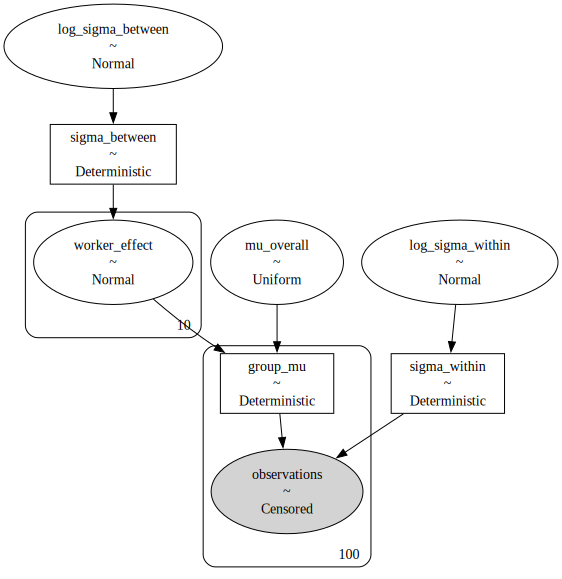

In [19]:
pm.model_to_graphviz(pymc_model)

In [20]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [21]:
np.median(np.exp(trace.posterior["sigma_between"].values.flatten()))

1.0850444175536098

In [22]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [23]:
# calculate posterior sample for 95th percentile

mu_chain = trace.posterior["mu_overall"].values.flatten()
sigma_chain = trace.posterior["sigma_within"].values.flatten()

interpretation(
    is_lognormal=True,
    mu_chain=mu_chain,
    sigma_chain=sigma_chain,
    probacred=90,
    oel=150,
    frac_threshold=10,
    target_perc=95
)

{'gm': {'est': 28.57, 'lcl': 24.396, 'ucl': 33.507},
 'gsd': {'est': 2.383, 'lcl': 2.171, 'ucl': 2.667},
 'frac': {'est': 2.818, 'lcl': 1.374, 'ucl': 5.23},
 'perc': {'est': 119.298, 'lcl': 95.944, 'ucl': 153.118},
 'am': {'est': 41.735, 'lcl': 35.091, 'ucl': 50.641},
 'frac.risk': 0.012,
 'perc.risk': 6.438,
 'am.risk': 0.0,
 'am.riskbands': {'<0.01*OEL': 0.0,
  '[0.01-0.1]*OEL': 0.0,
  '[0.1-0.5]*OEL': 99.997,
  '[0.5-1]*OEL': 0.003,
  '>OEL': 0.0}}

In [24]:
mu_overall = trace.posterior["mu_overall"].values.flatten()
sigma_within = trace.posterior["sigma_within"].values.flatten()
sigma_between = trace.posterior["sigma_between"].values.flatten()

worker_effect = trace.posterior["worker_effect"].values.reshape(len(trace.posterior["worker_effect"].values), -1)

In [38]:
def rho(sigma_within, sigma_between, probacred):
    chain = (sigma_between) / (sigma_between + sigma_within)
    est = np.median(chain)
    lcl = np.quantile(chain, (100 - probacred) / 200)
    ucl = np.quantile(chain, 1 - (100 - probacred) / 200)
    return {"est": est.round(2), "lcl": lcl.round(2), "ucl": ucl.round(2)}
    


In [39]:
sigma_within

array([0.93417011, 0.92894023, 0.86257075, ..., 0.83761766, 0.90359551,
       0.82704881])

In [40]:
rho(sigma_within, sigma_between, 90)

{'est': 0.09, 'lcl': 0.02, 'ucl': 0.23}